In [1]:
# 고전 컴퓨터비전(Classical CV) 실습 — Haar Cascade 얼굴 탐지(Object Detection)
#
# "미리 학습된 특정 물체(정면 얼굴)를 사각형 패턴(Haar-like features) 기반
# cascade 판별기로 탐지"하는 과정을 4개 계층으로 분리해 구현한다.
#
# Clean Architecture 레이어:
#   [도메인 계층]      — 값 객체(dataclass) + 추상 인터페이스(abc.ABC). cv2 비의존.
#   [유스케이스 계층]   — FaceDetectionUseCase. 인터페이스만 주입받아 흐름을 조립.
#   [인프라 계층]      — cv2 Haar Cascade 기반 실제 구현체(탐지/시각화를 분리).
#   [구성 루트]        — Colab 셀: 이미지 로드, DI 조립, matplotlib 시각화/저장.

## 셀 1: 환경 준비

In [2]:
!pip install opencv-python-headless scikit-image matplotlib numpy --quiet
# (한글 폰트가 없는 환경이면)
!apt-get -qq install -y fonts-nanum && fc-cache -f
from __future__ import annotations

import numpy as np
import matplotlib
from matplotlib import font_manager as _font_manager
import glob as _glob
for _font_path in _glob.glob("/usr/share/fonts/truetype/nanum/NanumGothic.ttf"):
    _font_manager.fontManager.addfont(_font_path)  # 폰트 매니저에 명시적으로 등록
matplotlib.rcParams["font.family"] = "NanumGothic"  # 그래프 한글 깨짐 방지
matplotlib.rcParams["axes.unicode_minus"] = False

# ===== [도메인 계층 / Domain Layer] =====

from abc import ABC, abstractmethod
from dataclasses import dataclass, field


@dataclass(frozen=True)
class BoundingBox:
    """탐지된 영역 하나를 나타내는 순수 값 객체. cv2 Rect 등 구체 타입에
    의존하지 않아, 다른 탐지기(예: DNN)로 바꿔도 그대로 재사용 가능하다."""
    x: int
    y: int
    width: int
    height: int

    @property
    def area(self) -> int:
        return self.width * self.height


@dataclass(frozen=True)
class FaceDetectionResult:
    original_rgb: np.ndarray
    gray_equalized: np.ndarray     # 전처리(히스토그램 평활화) 후 그레이스케일
    faces: list[BoundingBox] = field(default_factory=list)


class ImagePreprocessor(ABC):
    """탐지 정확도를 높이기 위한 전처리 책임만 갖는 작은 인터페이스 (ISP)."""

    @abstractmethod
    def to_detectable_gray(self, bgr_image: np.ndarray) -> np.ndarray:
        ...


class ObjectDetector(ABC):
    """"그레이스케일 이미지를 받아 바운딩박스 목록을 돌려준다"는 계약만
    정의한다. Haar Cascade든 DNN이든 이 인터페이스만 구현하면 교체 가능하다
    (OCP + DIP)."""

    @abstractmethod
    def detect(self, gray_image: np.ndarray) -> list[BoundingBox]:
        ...


# ===== [유스케이스 계층 / Use Case Layer] =====

class FaceDetectionUseCase:
    def __init__(self, preprocessor: ImagePreprocessor, detector: ObjectDetector):
        self._preprocessor = preprocessor
        self._detector = detector

    def run(self, bgr_image: np.ndarray, original_rgb: np.ndarray) -> FaceDetectionResult:
        gray = self._preprocessor.to_detectable_gray(bgr_image)
        faces = self._detector.detect(gray)
        return FaceDetectionResult(original_rgb=original_rgb, gray_equalized=gray, faces=faces)


# ===== [인프라/어댑터 계층 / Infrastructure Layer] =====

import cv2


class HistogramEqualizationPreprocessor(ImagePreprocessor):
    """명암 대비를 고르게 만들어(CLAHE) Haar Cascade가 밝기 패턴을 더 잘
    구분하게 돕는 cv2 어댑터."""

    def __init__(self):
        self._clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))

    def to_detectable_gray(self, bgr_image: np.ndarray) -> np.ndarray:
        gray = cv2.cvtColor(bgr_image, cv2.COLOR_BGR2GRAY)
        return self._clahe.apply(gray)


class HaarCascadeFaceDetector(ObjectDetector):
    """OpenCV에 내장된 사전학습 Haar Cascade(정면 얼굴) cv2 어댑터."""

    def __init__(
        self,
        scale_factor: float = 1.08,
        min_neighbors: int = 5,
        min_size: tuple[int, int] = (40, 40),
    ):
        cascade_path = cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
        self._cascade = cv2.CascadeClassifier(cascade_path)
        if self._cascade.empty():
            raise RuntimeError(f"Haar Cascade 모델 로드 실패: {cascade_path}")
        self._scale_factor = scale_factor
        self._min_neighbors = min_neighbors
        self._min_size = min_size

    def detect(self, gray_image: np.ndarray) -> list[BoundingBox]:
        rects = self._cascade.detectMultiScale(
            gray_image,
            scaleFactor=self._scale_factor,
            minNeighbors=self._min_neighbors,
            minSize=self._min_size,
        )
        return [BoundingBox(x=int(x), y=int(y), width=int(w), height=int(h)) for (x, y, w, h) in rects]


class FaceDetectionVisualizer:
    """시각화 전담 클래스(SRP) — 탐지 결과를 원본 위에 박스로 그려 저장한다."""

    def __init__(self, title: str, box_color=(0, 255, 90)):
        self._title = title
        self._box_color = box_color

    def save_result(self, result: FaceDetectionResult, out_path: str) -> None:
        import matplotlib.pyplot as plt
        import matplotlib.patches as patches

        fig, axes = plt.subplots(1, 2, figsize=(12, 6))
        fig.suptitle(self._title, fontsize=14, fontweight="bold")

        axes[0].imshow(result.gray_equalized, cmap="gray")
        axes[0].set_title("1. 전처리 (CLAHE 평활화, 그레이스케일)")
        axes[0].axis("off")

        axes[1].imshow(result.original_rgb)
        axes[1].set_title(f"2. Haar Cascade 탐지 결과 ({len(result.faces)}개 얼굴)")
        axes[1].axis("off")
        for box in result.faces:
            rect = patches.Rectangle(
                (box.x, box.y), box.width, box.height,
                linewidth=2.5, edgecolor="#00FF5A", facecolor="none",
            )
            axes[1].add_patch(rect)

        plt.tight_layout()
        plt.savefig(out_path, dpi=120, bbox_inches="tight")
        plt.show()
        print(f"저장 완료: {out_path} / 탐지된 얼굴 수: {len(result.faces)}")


# ===== [구성 루트 / Composition Root — Colab 실행 코드] =====

Selecting previously unselected package fonts-nanum.
(Reading database ... 122809 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.15.0-1.1ubuntu2) ...


## 셀 2: 테스트 이미지 준비 (scikit-image 내장 샘플 — 사람 얼굴 포함)

In [8]:
from skimage import data as skdata

astronaut_rgb = skdata.astronaut()
astronaut_bgr = cv2.cvtColor(astronaut_rgb, cv2.COLOR_RGB2BGR)
print("입력 이미지 크기:", astronaut_bgr.shape)

입력 이미지 크기: (512, 512, 3)


## 셀 3: 구체 어댑터 생성 + 의존성 주입(DIP)

In [9]:
preprocessor: ImagePreprocessor = HistogramEqualizationPreprocessor()
detector: ObjectDetector = HaarCascadeFaceDetector(scale_factor=1.08, min_neighbors=5, min_size=(40, 40))

use_case = FaceDetectionUseCase(preprocessor=preprocessor, detector=detector)

## 셀 4: 실행

In [10]:
result = use_case.run(astronaut_bgr, astronaut_rgb)
print("탐지된 얼굴 바운딩박스:", result.faces)

탐지된 얼굴 바운딩박스: [BoundingBox(x=176, y=65, width=99, height=99)]


## 셀 5: 결과 시각화 및 저장

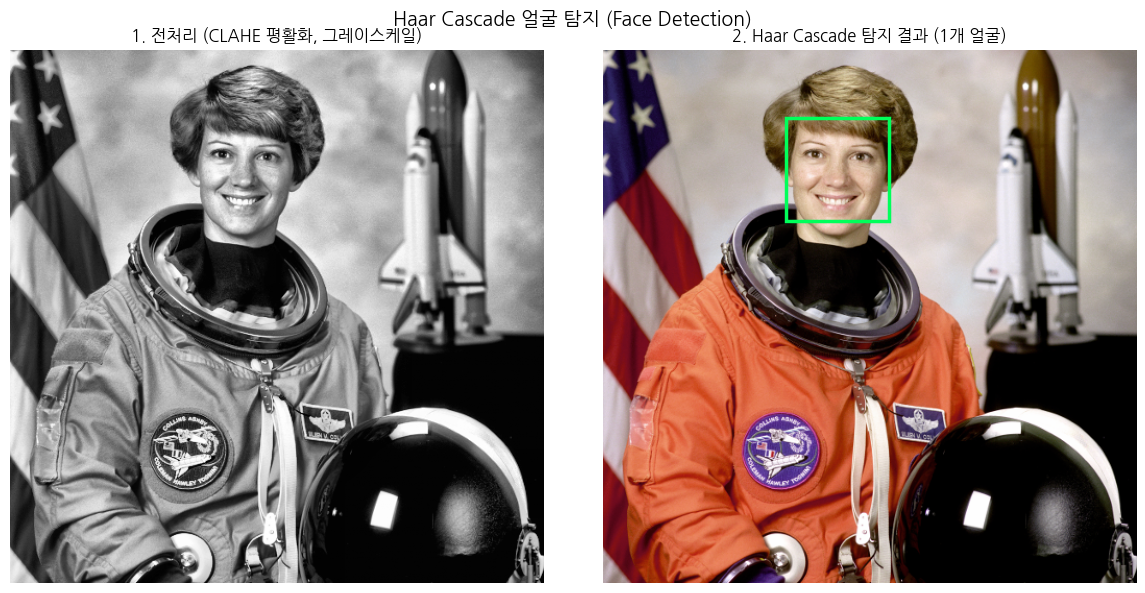

저장 완료: haar_cascade_result.png / 탐지된 얼굴 수: 1


In [11]:
visualizer = FaceDetectionVisualizer(title="Haar Cascade 얼굴 탐지 (Face Detection)")
visualizer.save_result(result, "haar_cascade_result.png")

## 셀 6: (선택) 파라미터(minNeighbors)를 바꿔가며 비교 — OCP 확인용

In [12]:
# HaarCascadeFaceDetector는 새 설정으로 "새 인스턴스"를 만들기만 하면 되고,
# FaceDetectionUseCase/도메인 계층은 한 줄도 수정하지 않는다.
for min_neighbors in [3, 5, 8]:
    d = HaarCascadeFaceDetector(min_neighbors=min_neighbors)
    r = FaceDetectionUseCase(preprocessor, d).run(astronaut_bgr, astronaut_rgb)
    print(f"minNeighbors={min_neighbors} -> 탐지 {len(r.faces)}개 (값이 클수록 더 엄격하게 판정)")

minNeighbors=3 -> 탐지 1개 (값이 클수록 더 엄격하게 판정)
minNeighbors=5 -> 탐지 1개 (값이 클수록 더 엄격하게 판정)
minNeighbors=8 -> 탐지 1개 (값이 클수록 더 엄격하게 판정)
